# AUTOENCODERS - UNET

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
#@title **Load libraries**
#@markdown Here is important to change to GPU

import os
import cv2
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm_notebook, tnrange

from itertools import chain
from skimage.morphology import label
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from skimage.io import imread, imshow, concatenate_images

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import concatenate, add
from tensorflow.keras.layers import Lambda, RepeatVector, Reshape
from tensorflow.keras.layers import Conv2D, Conv2DTranspose
from tensorflow.keras.layers import MaxPooling2D, GlobalMaxPool2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Input, BatchNormalization, Activation, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator  #img_to_array, array_to_img, load_img

ModuleNotFoundError: No module named 'cv2'

# **1. Semantic segmentation** <a name="Semant_seg"></a>

Image classification gives a **discrete labeled answer (image dimension)** from an image input with **objects of interest** into a particular scene. This task is much more complex, including localization, detection, and spatial object boundary.

For **_semantic segmentation_** specifically the task is associated **to each pixel** with a semantic label produced by a machine learning algorithm. This task is known as a **dense prediction** and the result is useful for many different scenarios, areas and applications. In figure you can observe applications related with **autonomous vehicles** for planning and detection of traffic signs, to support **biomedical image diagnosis**, for **agriculture precision** to reduce herbicides and smart control.

<center>
<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/segmentation.png" style="width:700px;heigth:100px">
</center>

Nowadays, there exist more sophisticated models that try **instance segmentation** with the idea to obtain a per-pixel segmentation but for **multiclass** problems.

# **2. UNET: an autoencoder to segmentation** <a name="Unet"></a>

### **The architecture of UNET**

<center>
<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/unet.png"  width="700">
</center>
So, how looks an UNET-code... **go to the action!**

In [ ]:
#@title **Coding** Create the pair of UNET convolutions
def conv2d_block(input_tensor, n_filters, kernel_size = 3, batchnorm = True):
    """Function to add 2 convolutional layers with the parameters passed to it"""
    # First layer
    x = Conv2D(filters = n_filters, kernel_size = (kernel_size, kernel_size),\
              kernel_initializer = 'he_normal', padding = 'same')(input_tensor)
    if batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Second layer
    x = Conv2D(filters = n_filters, kernel_size = (kernel_size, kernel_size),\
              kernel_initializer = 'he_normal', padding = 'same')(input_tensor)
    if batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)

    return x


In [ ]:
 #@title **Coding** A nice UNET function
 def get_unet(input_img, n_filters = 16, dropout = 0.1, batchnorm = True):

    # Contracting Path
    c1 = conv2d_block(input_img, n_filters * 1, kernel_size = 3, batchnorm = batchnorm)
    p1 = MaxPooling2D((2, 2))(c1)
    p1 = Dropout(dropout)(p1)

    c2 = conv2d_block(p1, n_filters * 2, kernel_size = 3, batchnorm = batchnorm)
    p2 = MaxPooling2D((2, 2))(c2)
    p2 = Dropout(dropout)(p2)

    c3 = conv2d_block(p2, n_filters * 4, kernel_size = 3, batchnorm = batchnorm)
    p3 = MaxPooling2D((2, 2))(c3)
    p3 = Dropout(dropout)(p3)

    c4 = conv2d_block(p3, n_filters * 8, kernel_size = 3, batchnorm = batchnorm)
    p4 = MaxPooling2D((2, 2))(c4)
    p4 = Dropout(dropout)(p4)

    c5 = conv2d_block(p4, n_filters = n_filters * 16, kernel_size = 3, batchnorm = batchnorm)

    # Expansive Path
    u6 = Conv2DTranspose(n_filters * 8, (3, 3), strides = (2, 2), padding = 'same')(c5)
    u6 = concatenate([u6, c4])
    u6 = Dropout(dropout)(u6)
    c6 = conv2d_block(u6, n_filters * 8, kernel_size = 3, batchnorm = batchnorm)

    u7 = Conv2DTranspose(n_filters * 4, (3, 3), strides = (2, 2), padding = 'same')(c6)
    u7 = concatenate([u7, c3])
    u7 = Dropout(dropout)(u7)
    c7 = conv2d_block(u7, n_filters * 4, kernel_size = 3, batchnorm = batchnorm)

    u8 = Conv2DTranspose(n_filters * 2, (3, 3), strides = (2, 2), padding = 'same')(c7)
    u8 = concatenate([u8, c2])
    u8 = Dropout(dropout)(u8)
    c8 = conv2d_block(u8, n_filters * 2, kernel_size = 3, batchnorm = batchnorm)

    u9 = Conv2DTranspose(n_filters * 1, (3, 3), strides = (2, 2), padding = 'same')(c8)
    u9 = concatenate([u9, c1])
    u9 = Dropout(dropout)(u9)
    c9 = conv2d_block(u9, n_filters * 1, kernel_size = 3, batchnorm = batchnorm)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
    model = Model(inputs=[input_img], outputs=[outputs])
    return model

# **3. UNET application 1**  <a name="Unet_1"></a>
### **Nuclei segmentation**

A very important task is automate nucleus detection and segmentation. The task of classifying, identifying, and segmenting cell nuclei is very important in many clinical tasks, such as: quantifying disorders, diseases related to cancer, understand treatment responses, among others. The image data was taken from [data-science-bowl-2018](https://www.kaggle.com/c/data-science-bowl-2018)

<center>
<img src="https://storage.googleapis.com/kaggle-media/competitions/dsb-2018/dsb.jpg" width="700">
</center>





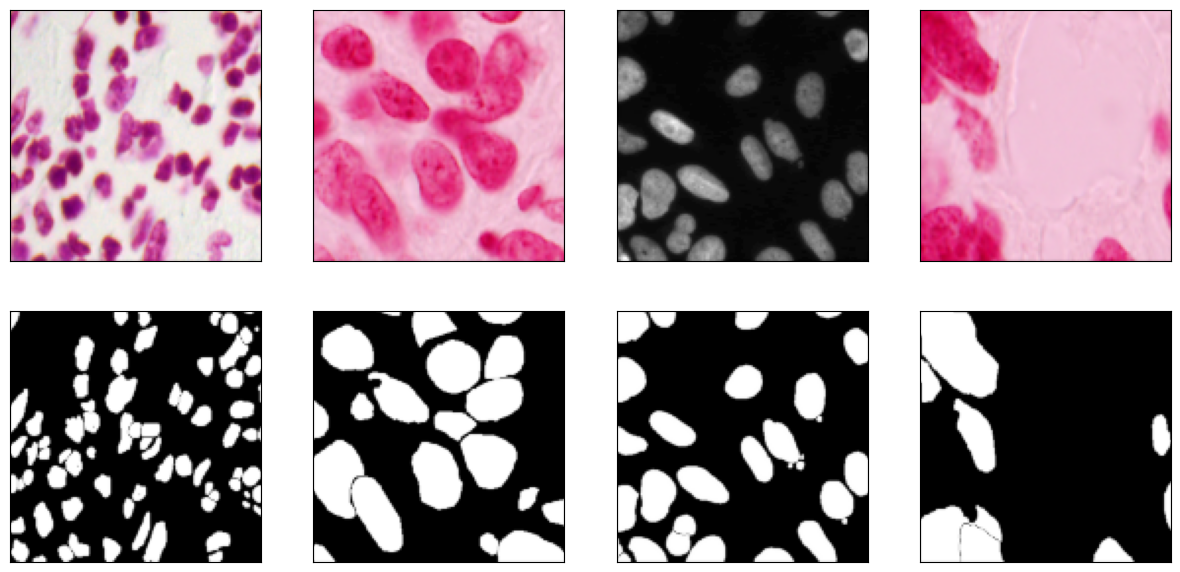

In [ ]:
#@title **Coding** Let's show some examples
path = '/content/drive/My Drive/notebooks-ia2/5-Autoencoders/bowl-2018/'


plt.figure(figsize=(15,15))
plt.subplot(441), plt.imshow(cv2.imread(os.path.join(path,'imgs', '71.png'))), plt.xticks([]), plt.yticks([]);
plt.subplot(442), plt.imshow(cv2.imread(os.path.join(path,'imgs', '68.png'))), plt.xticks([]), plt.yticks([]);
plt.subplot(443), plt.imshow(cv2.imread(os.path.join(path,'imgs', '94.png'))),plt.xticks([]), plt.yticks([]);
plt.subplot(444), plt.imshow(cv2.imread(os.path.join(path,'imgs', '114.png'))),plt.xticks([]), plt.yticks([]);
plt.subplot(445), plt.imshow(cv2.imread(os.path.join(path,'masks', '71.png'))), plt.xticks([]), plt.yticks([]);
plt.subplot(446), plt.imshow(cv2.imread(os.path.join(path,'masks', '68.png'))), plt.xticks([]), plt.yticks([]);
plt.subplot(447), plt.imshow(cv2.imread(os.path.join(path,'masks', '94.png'))),plt.xticks([]), plt.yticks([]);
plt.subplot(448), plt.imshow(cv2.imread(os.path.join(path,'masks', '114.png'))),plt.xticks([]), plt.yticks([]);


In [ ]:
#@title **Coding** To load the dataset
path = '/content/drive/My Drive/notebooks-ia2/5-Autoencoders/bowl-2018/'
# Create each array of the images and the corresponding mask
imgs_l = []; masks_l =[]

# List them all
imgs = os.listdir(path + 'imgs')
masks = os.listdir(path + 'masks')

# Time to sort
imgs.sort(); masks.sort()

# How can we obtain each path?
imgs = [os.path.join(path, 'imgs', img) for img in imgs]
masks = [os.path.join(path, 'masks', mask) for mask in masks]

# Load each image
imgs_l = [cv2.imread(img) for img in imgs]
masks_l = [cv2.imread(mask,0) for mask in masks]

# Normalize all the data
print("Images: ", len(imgs_l), "Masks: ",  len(masks_l), "Shape of an specific image: ", imgs_l[0].shape)
X = np.array(imgs_l)/255.0
y = np.array(masks_l)/255.0
print("X samples value: ", X.shape, "Y samples value: ", y.shape, "Max value on X: ", np.max(X), "Min value on X", np.min(X))
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.1, random_state=42)

Images:  670 Masks:  670 Shape of an specific image:  (128, 128, 3)
X samples value:  (670, 128, 128, 3) Y samples value:  (670, 128, 128) Max value on X:  1.0 Min value on X 0.0


In [ ]:
#@title **Coding** Charge, prepare and tune the model
input_img = Input((128, 128, 3), name='img')
model = get_unet(input_img, n_filters=16, dropout=0.05, batchnorm=True)
model.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img (InputLayer)    │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │        448 │ img[0][0]         │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      4,640 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     18,496 │ dropout_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │     73,856 │ dropout_2[0][0] 

 Total params: 1,179,409 (4.50 MB)

 Trainable params: 1,177,937 (4.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
#@title **Coding** Time to train the model! :)
earlystopper = EarlyStopping(patience=3, verbose=1)
checkpointer = ModelCheckpoint('model_cell_unet.h5', verbose=1, save_best_only=True)
results = model.fit(X_train, y_train, batch_size=32,
                    callbacks=[earlystopper, checkpointer],
                    epochs=50,validation_data=(X_valid, y_valid))


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7915 - loss: 0.4683  
Epoch 1: val_loss improved from None to 0.58118, saving model to model_cell_unet.h5



Epoch 1: finished saving model to model_cell_unet.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8128 - loss: 0.4048 - val_accuracy: 0.7871 - val_loss: 0.5812
Epoch 2/50
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8434 - loss: 0.2818
Epoch 2: val_loss improved from 0.58118 to 0.45746, saving model to model_cell_unet.h5



Epoch 2: finished saving model to model_cell_unet.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8505 - loss: 0.2678 - val_accuracy: 0.8300 - val_loss: 0.4575
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8518 - loss: 0.2282
Epoch 3: val_loss did not improve from 0.45746
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8544 - loss: 0.2259 - val_accuracy: 0.8190 - val_loss: 0.4971
Epoch 4/50
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8523 - loss: 0.2101
Epoch 4: val_loss improved from 0.45746 to 0.40906, saving model to model_cell_unet.h5



Epoch 4: finished saving model to model_cell_unet.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.8577 - loss: 0.2019 - val_accuracy: 0.7673 - val_loss: 0.4091
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8584 - loss: 0.1839
Epoch 5: val_loss improved from 0.40906 to 0.27596, saving model to model_cell_unet.h5



Epoch 5: finished saving model to model_cell_unet.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8625 - loss: 0.1778 - val_accuracy: 0.8487 - val_loss: 0.2760
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8638 - loss: 0.1618
Epoch 6: val_loss improved from 0.27596 to 0.24396, saving model to model_cell_unet.h5


...


Epoch 29: finished saving model to model_cell_unet.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8654 - loss: 0.0868 - val_accuracy: 0.8670 - val_loss: 0.0877
Epoch 30/50
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8632 - loss: 0.0880
Epoch 30: val_loss did not improve from 0.08771
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8657 - loss: 0.0843 - val_accuracy: 0.8665 - val_loss: 0.0884
Epoch 31/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8587 - loss: 0.0859
Epoch 31: val_loss improved from 0.08771 to 0.08742, saving model to model_cell_unet.h5



Epoch 31: finished saving model to model_cell_unet.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8655 - loss: 0.0844 - val_accuracy: 0.8669 - val_loss: 0.0874
Epoch 32/50
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8720 - loss: 0.0801
Epoch 32: val_loss improved from 0.08742 to 0.08507, saving model to model_cell_unet.h5



Epoch 32: finished saving model to model_cell_unet.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8656 - loss: 0.0832 - val_accuracy: 0.8671 - val_loss: 0.0851
Epoch 33/50
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8682 - loss: 0.0788
Epoch 33: val_loss did not improve from 0.08507
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8658 - loss: 0.0820 - val_accuracy: 0.8659 - val_loss: 0.0886
Epoch 34/50
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8634 - loss: 0.0809
Epoch 34: val_loss did not improve from 0.08507
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8658 - loss: 0.0818 - val_accuracy: 0.8671 - val_loss: 0.0866
Epoch 35/50
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8588 - loss: 0.0888
Epoch 35: val_loss improved from 0.08507 to 0.08410, saving model to model_cell_unet.h5



Epoch 35: finished saving model to model_cell_unet.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8657 - loss: 0.0824 - val_accuracy: 0.8668 - val_loss: 0.0841
Epoch 36/50
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8621 - loss: 0.0795
Epoch 36: val_loss did not improve from 0.08410
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.8663 - loss: 0.0792 - val_accuracy: 0.8663 - val_loss: 0.0861
Epoch 37/50
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8616 - loss: 0.0794
Epoch 37: val_loss did not improve from 0.08410
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8662 - loss: 0.0791 - val_accuracy: 0.8666 - val_loss: 0.0847
Epoch 38/50
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8659 - loss: 0.0797
Epoch 38: val_loss improved from 0.08410 to 0.08140, saving model to model_cell_unet.h5



Epoch 38: finished saving model to model_cell_unet.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8662 - loss: 0.0783 - val_accuracy: 0.8671 - val_loss: 0.0814
Epoch 39/50
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8607 - loss: 0.0804
Epoch 39: val_loss did not improve from 0.08140
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.8663 - loss: 0.0777 - val_accuracy: 0.8667 - val_loss: 0.0822
Epoch 40/50
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8707 - loss: 0.0742
Epoch 40: val_loss did not improve from 0.08140
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8667 - loss: 0.0759 - val_accuracy: 0.8669 - val_loss: 0.0824
Epoch 41/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8669 - loss: 0.0756
Epoch 41: val_loss did not improve from 0.08140
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8668 - loss: 0.0751 - val_accuracy: 0.8667 - val_loss: 0.0829
Epoch 41: early stopping


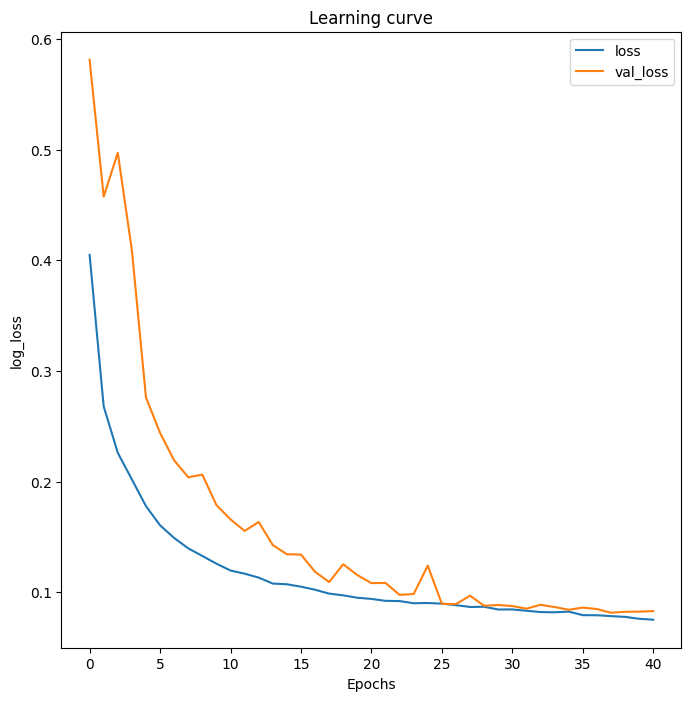

In [ ]:
#@title **Coding** To show train and test performance
plt.figure(figsize=(8, 8))
plt.title("Learning curve")
plt.plot(results.history["loss"], label="loss")
plt.plot(results.history["val_loss"], label="val_loss")
plt.xlabel("Epochs")
plt.ylabel("log_loss")
plt.legend();

In [ ]:
#if the model takes too long
new_model2 = tf.keras.models.load_model('model_cell_unet.h5')

In [ ]:
#@title **Coding** What about each prediction?
preds_train = model.predict(X_train, verbose=1)
preds_val = model.predict(X_valid, verbose=1)

preds_val.shape, preds_train.shape
# Threshold predictions
preds_train_t = (preds_train > 0.5).astype(np.uint8)
preds_val_t = (preds_val > 0.5).astype(np.uint8)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step


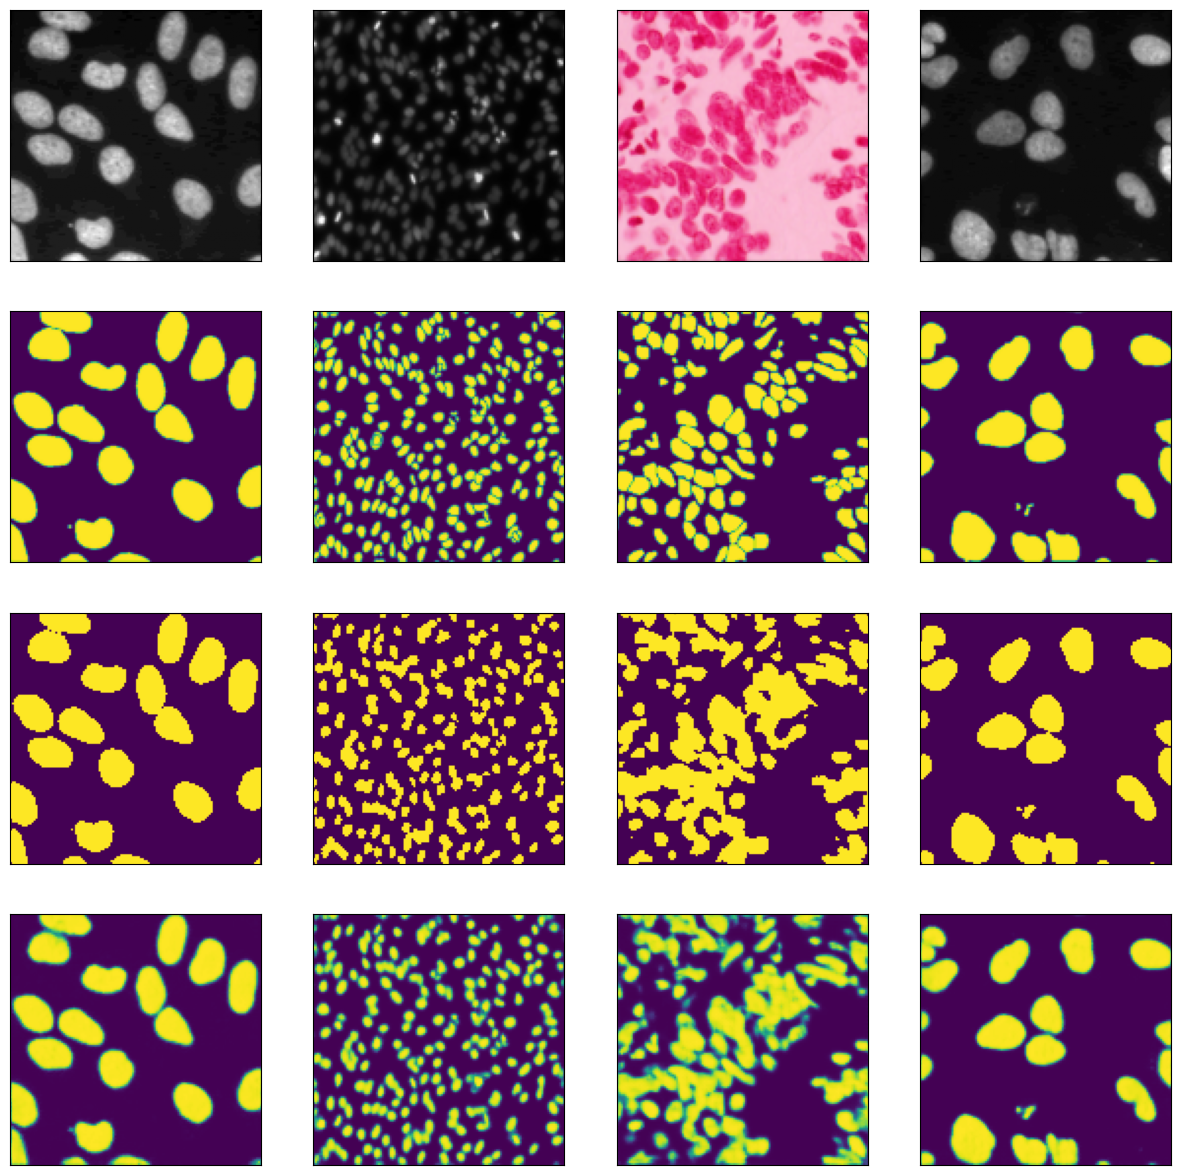

In [ ]:
#@title **Coding** Some results
ex_1 = 21 #@param {type:"integer"}
ex_2 = 15 #@param {type:"integer"}
ex_3 = 23 #@param {type:"integer"}
ex_4 =  0 #@param {type:"integer"}

plt.figure(figsize=(15,15))

plt.subplot(441), plt.imshow(X_valid[ex_1]), plt.xticks([]), plt.yticks([]);
plt.subplot(442), plt.imshow(X_valid[ex_2]), plt.xticks([]), plt.yticks([]);
plt.subplot(443), plt.imshow(X_valid[ex_3]), plt.xticks([]), plt.yticks([]);
plt.subplot(444), plt.imshow(X_valid[ex_4]), plt.xticks([]), plt.yticks([]);

plt.subplot(445), plt.imshow(y_valid[ex_1]), plt.xticks([]), plt.yticks([]);
plt.subplot(446), plt.imshow(y_valid[ex_2]), plt.xticks([]), plt.yticks([]);
plt.subplot(447), plt.imshow(y_valid[ex_3]), plt.xticks([]), plt.yticks([]);
plt.subplot(448), plt.imshow(y_valid[ex_4]), plt.xticks([]), plt.yticks([]);

plt.subplot(449), plt.imshow(np.squeeze(preds_val_t[ex_1])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,10), plt.imshow(np.squeeze(preds_val_t[ex_2])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,11), plt.imshow(np.squeeze(preds_val_t[ex_3])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,12), plt.imshow(np.squeeze(preds_val_t[ex_4])), plt.xticks([]), plt.yticks([]);

plt.subplot(4,4,13), plt.imshow(np.squeeze(preds_val[ex_1])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,14), plt.imshow(np.squeeze(preds_val[ex_2])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,15), plt.imshow(np.squeeze(preds_val[ex_3])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,16), plt.imshow(np.squeeze(preds_val[ex_4])), plt.xticks([]), plt.yticks([]);

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

- Try a more restrictive data learning. Only take 50 % and 20% of training data. Visualize and analyze the results. What happened?

In [ ]:
#Crear subsets de datos de entrenamiento

# ────────────────────────────────────────────────────
# ¿Cuántos ejemplos tenemos en total para entrenar?
total_train = len(X_train)
print(f"Total ejemplos de entrenamiento (100%): {total_train}")

# ── 50% de los datos ──
n_50 = int(total_train * 0.5)   # Calcula cuántos son el 50%
X_train_50 = X_train[:n_50]     # Toma los primeros n_50 ejemplos
y_train_50 = y_train[:n_50]
print(f"Ejemplos al 50%: {len(X_train_50)}")

# ── 20% de los datos ──
n_20 = int(total_train * 0.2)   # Calcula cuántos son el 20%
X_train_20 = X_train[:n_20]     # Toma los primeros n_20 ejemplos
y_train_20 = y_train[:n_20]
print(f"Ejemplos al 20%: {len(X_train_20)}")


In [ ]:
#Modelo con 50% de datos de entrenamiento
# Crear un modelo nuevo (misma arquitectura, pesos inicializados desde cero)
input_img_50 = Input((128, 128, 3), name='img_50')
model_50 = get_unet(input_img_50, n_filters=16, dropout=0.05, batchnorm=True)
model_50.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=["accuracy"])
# Callbacks: igual que el modelo original
earlystopper_50 = EarlyStopping(patience=3, verbose=1)
checkpointer_50 = ModelCheckpoint('model_cell_unet_50.h5', verbose=1, save_best_only=True)
# Entrenar con solo el 50% de los datos
print("=== Entrenando con 50% de datos ===")
results_50 = model_50.fit(
    X_train_50, y_train_50,          # ← Solo el 50%
    batch_size=32,
    callbacks=[earlystopper_50, checkpointer_50],
    epochs=50,
    validation_data=(X_valid, y_valid)   # ← Validación igual para todos
)

In [ ]:
#Modelo con 20% de datos de entrenamiento

# Crear otro modelo nuevo
input_img_20 = Input((128, 128, 3), name='img_20')
model_20 = get_unet(input_img_20, n_filters=16, dropout=0.05, batchnorm=True)
model_20.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=["accuracy"])

# Callbacks para el modelo del 20%
earlystopper_20 = EarlyStopping(patience=3, verbose=1)
checkpointer_20 = ModelCheckpoint('model_cell_unet_20.h5', verbose=1, save_best_only=True)

# Entrenar con solo el 20% de los datos
print("=== Entrenando con 20% de datos ===")
results_20 = model_20.fit(
    X_train_20, y_train_20,          # ← Solo el 20%
    batch_size=32,
    callbacks=[earlystopper_20, checkpointer_20],
    epochs=50,
    validation_data=(X_valid, y_valid)   # ← Validación igual para todos
)


In [ ]:
#Visualización y análisis comparativo


# PARTE 1: Comparar curvas de aprendizaje

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Challenge 1: Comparación de curvas de aprendizaje", fontsize=14)

# Gráfica 100%
axes[0].plot(results.history["loss"], label="train loss", color='blue')
axes[0].plot(results.history["val_loss"], label="val loss", color='orange')
axes[0].set_title("100% de datos de entrenamiento")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Gráfica 50%
axes[1].plot(results_50.history["loss"], label="train loss", color='blue')
axes[1].plot(results_50.history["val_loss"], label="val loss", color='orange')
axes[1].set_title("50% de datos de entrenamiento")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Loss")
axes[1].legend()

# Gráfica 20%
axes[2].plot(results_20.history["loss"], label="train loss", color='blue')
axes[2].plot(results_20.history["val_loss"], label="val loss", color='orange')
axes[2].set_title("20% de datos de entrenamiento")
axes[2].set_xlabel("Épocas")
axes[2].set_ylabel("Loss")
axes[2].legend()

plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════
# PARTE 2: Comparar predicciones visuales
# ═══════════════════════════════════════════════

# Generar predicciones de los 3 modelos sobre los MISMOS datos de validación
preds_val_100 = (model.predict(X_valid, verbose=0) > 0.5).astype(np.uint8)    # ya existe como preds_val_t
preds_val_50  = (model_50.predict(X_valid, verbose=0) > 0.5).astype(np.uint8)
preds_val_20  = (model_20.predict(X_valid, verbose=0) > 0.5).astype(np.uint8)

# Elegir 3 ejemplos para comparar (puedes cambiar estos índices)
ejemplos = [0, 5, 10]

fig, axes = plt.subplots(len(ejemplos), 5, figsize=(18, 4 * len(ejemplos)))
fig.suptitle("Challenge 1: Comparación de predicciones", fontsize=14)

# Encabezados de columnas
col_titles = ['Original', 'Máscara Real', 'Pred. 100%', 'Pred. 50%', 'Pred. 20%']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, fontweight='bold')

for fila, idx in enumerate(ejemplos):
    # Columna 0: imagen original
    axes[fila, 0].imshow(X_valid[idx])
    axes[fila, 0].axis('off')

    # Columna 1: máscara real (ground truth)
    axes[fila, 1].imshow(y_valid[idx], cmap='gray')
    axes[fila, 1].axis('off')

    # Columna 2: predicción con 100% de datos
    axes[fila, 2].imshow(np.squeeze(preds_val_100[idx]), cmap='gray')
    axes[fila, 2].axis('off')

    # Columna 3: predicción con 50% de datos
    axes[fila, 3].imshow(np.squeeze(preds_val_50[idx]), cmap='gray')
    axes[fila, 3].axis('off')

    # Columna 4: predicción con 20% de datos
    axes[fila, 4].imshow(np.squeeze(preds_val_20[idx]), cmap='gray')
    axes[fila, 4].axis('off')

plt.tight_layout()
plt.show()




# **4. UNET application 2** <a name="Unet_2"></a>


Seismic data is captured from seismic reflection, similar to X-ray, sonar and echolocation. In this dataset is collected a set of images that try to detect several areas of the world where there are vast quantities of salt in the subsurface. The sequence of images was taken from the dataset [tgs-salt-identification-challenge](https://www.kaggle.com/c/tgs-salt-identification-challenge/data)


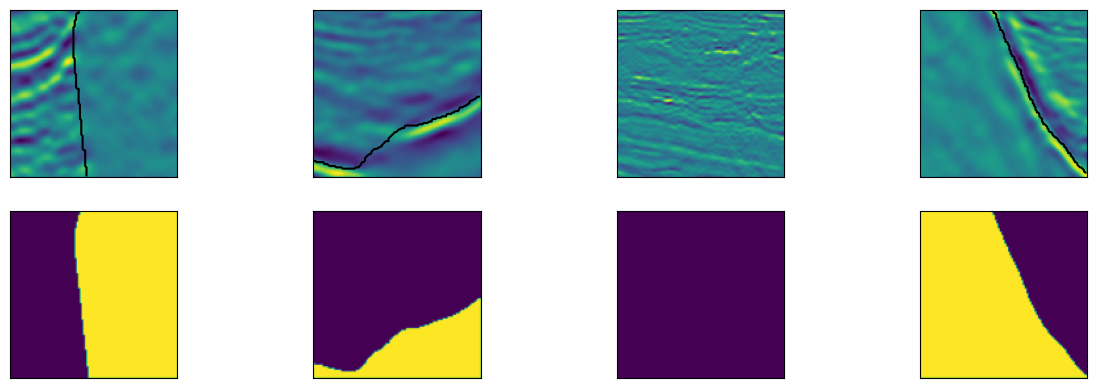

In [ ]:
# @title **Coding** We need to visualize segmentation challenge

path ='/content/drive/My Drive/notebooks-ia2/5-Autoencoders/tgsalt/'


plt.figure(figsize=(15,10))
ax1= plt.subplot(441), plt.imshow(cv2.imread(os.path.join(path,'imgs', '711.png'),0)), plt.xticks([]), plt.yticks([]);
ax1= plt.contour(cv2.imread(os.path.join(path,'masks', '711.png'),0), colors='k', levels=[0.5]);
ax2= plt.subplot(442), plt.imshow(cv2.imread(os.path.join(path,'imgs', '618.png'),0)), plt.xticks([]), plt.yticks([]);
ax2= plt.contour(cv2.imread(os.path.join(path,'masks', '618.png'),0), colors='k', levels=[0.5]);
ax3=plt.subplot(443), plt.imshow(cv2.imread(os.path.join(path,'imgs', '914.png'),0)),plt.xticks([]), plt.yticks([]);
ax3= plt.contour(cv2.imread(os.path.join(path,'masks', '914.png'),0), colors='k', levels=[0.5]);
ax4=plt.subplot(444), plt.imshow(cv2.imread(os.path.join(path,'imgs', '1114.png'),0)),plt.xticks([]), plt.yticks([]);
ax4= plt.contour(cv2.imread(os.path.join(path,'masks', '1114.png'),0), colors='k', levels=[0.5]);
ax5=plt.subplot(445), plt.imshow(cv2.imread(os.path.join(path,'masks', '711.png'),0)), plt.xticks([]), plt.yticks([]);
ax6=plt.subplot(446), plt.imshow(cv2.imread(os.path.join(path,'masks', '618.png'),0)), plt.xticks([]), plt.yticks([]);
ax7=plt.subplot(447), plt.imshow(cv2.imread(os.path.join(path,'masks', '914.png'),0)),plt.xticks([]), plt.yticks([]);
ax8=plt.subplot(448), plt.imshow(cv2.imread(os.path.join(path,'masks', '1114.png'),0)),plt.xticks([]), plt.yticks([]);


In [ ]:
#@title **Coding** To load the dataset
path = '/content/drive/My Drive/notebooks-ia2/5-Autoencoders/tgsalt/'
# Create each array of the images and the corresponding mask
imgs_l = []; masks_l =[]

# List them all
imgs = os.listdir(path + 'imgs')
masks = os.listdir(path + 'masks')

# Time to sort
imgs.sort(); masks.sort()

# How can we obtain each path?
imgs = [os.path.join(path, 'imgs', img) for img in imgs]
masks = [os.path.join(path, 'masks', mask) for mask in masks]

# Load each image
imgs_l = [cv2.imread(img) for img in imgs]
masks_l = [cv2.imread(mask,0) for mask in masks]

# Normalize all the data
print("Images: ", len(imgs_l), "Masks: ",  len(masks_l), "Shape of an specific image: ", imgs_l[0].shape)
X = np.array(imgs_l)/255.0
y = np.array(masks_l)/255.0
print("X samples value: ", X.shape, "Y samples value: ", y.shape, "Max value on X: ", np.max(X), "Min value on X", np.min(X))
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.1, random_state=42)

Images:  4000 Masks:  4000 Shape of an specific image:  (128, 128, 3)
X samples value:  (4000, 128, 128, 3) Y samples value:  (4000, 128, 128) Max value on X:  1.0 Min value on X 0.0


In [ ]:
# @title **Coding** Time to load a pre-trained unet model
model = tf.keras.models.load_model('models/model_tgsalt_unet.h5')
model.summary()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'models/model_tgsalt_unet.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
#@title **Coding** What if we need to predict?
preds_train = model.predict(X_train, verbose=1)
preds_val = model.predict(X_valid, verbose=1)

preds_val.shape, preds_train.shape
# Threshold predictions
preds_train_t = (preds_train > 0.5).astype(np.uint8)
preds_val_t = (preds_val > 0.5).astype(np.uint8)

In [ ]:
#@title **code** Some visual results
ex_1 =  21#@param {type:"integer"}
ex_2 = 15 #@param {type:"integer"}
ex_3 = 23 #@param {type:"integer"}
ex_4 =  300#@param {type:"integer"}

plt.figure(figsize=(15,15))

plt.subplot(441), plt.imshow(X_valid[ex_1]), plt.xticks([]), plt.yticks([]);
plt.subplot(442), plt.imshow(X_valid[ex_2]), plt.xticks([]), plt.yticks([]);
plt.subplot(443), plt.imshow(X_valid[ex_3]), plt.xticks([]), plt.yticks([]);
plt.subplot(444), plt.imshow(X_valid[ex_4]), plt.xticks([]), plt.yticks([]);

plt.subplot(445), plt.imshow(y_valid[ex_1]), plt.xticks([]), plt.yticks([]);
plt.subplot(446), plt.imshow(y_valid[ex_2]), plt.xticks([]), plt.yticks([]);
plt.subplot(447), plt.imshow(y_valid[ex_3]), plt.xticks([]), plt.yticks([]);
plt.subplot(448), plt.imshow(y_valid[ex_4]), plt.xticks([]), plt.yticks([]);

plt.subplot(449), plt.imshow(np.squeeze(preds_val_t[ex_1])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,10), plt.imshow(np.squeeze(preds_val_t[ex_2])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,11), plt.imshow(np.squeeze(preds_val_t[ex_3])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,12), plt.imshow(np.squeeze(preds_val_t[ex_4])), plt.xticks([]), plt.yticks([]);

plt.subplot(4,4,13), plt.imshow(np.squeeze(preds_val[ex_1])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,14), plt.imshow(np.squeeze(preds_val[ex_2])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,15), plt.imshow(np.squeeze(preds_val[ex_3])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,16), plt.imshow(np.squeeze(preds_val[ex_4])), plt.xticks([]), plt.yticks([]);

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

- Evaluate other images and enjoy!
- put contours over images to analyze model perfomance




In [ ]:
#@title **Student code** Charge, prepare and tune the model
print(f"Training samples  : {X_train.shape}")
print(f"Validation samples: {X_valid.shape}")
print(f"Train masks shape : {y_train.shape}")
print(f"Valid masks shape : {y_valid.shape}")


In [ ]:
#@title **Student code** Time to train the model!
input_img = Input((128, 128, 3), name='img')
model = get_unet(input_img, n_filters=16, dropout=0.1, batchnorm=True)
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


In [ ]:
#@title **Student code** Time to show train and test performance

plt.figure(figsize=(8, 8))
plt.title("Learning curve - TGS Salt segmentation")
plt.plot(results.history['loss'], label='train loss')
plt.plot(results.history['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
#@title **Code** What about the prediction?
preds_train = model.predict(X_train, verbose=1)
preds_val = model.predict(X_valid, verbose=1)

preds_val.shape, preds_train.shape
# Threshold predictions
preds_train_t = (preds_train > 0.5).astype(np.uint8)
preds_val_t = (preds_val > 0.5).astype(np.uint8)

13/13 [==============================] - 0s 17ms/step


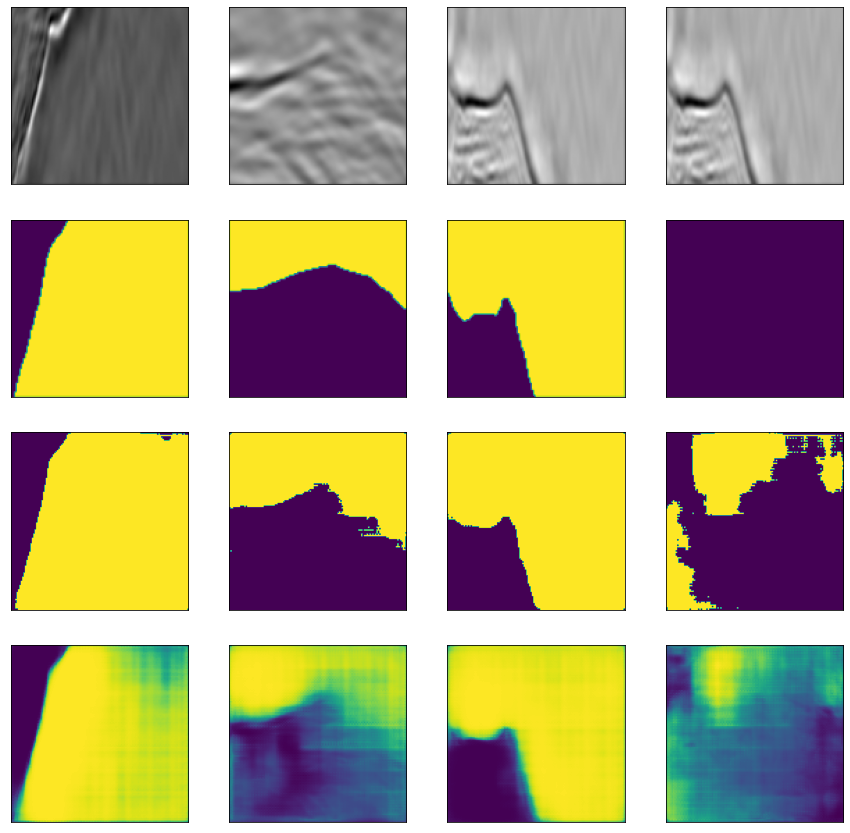

In [ ]:
#@title **Coding** Some results
ex_1 =  21#@param {type:"integer"}
ex_2 = 15 #@param {type:"integer"}
ex_3 = 23 #@param {type:"integer"}
ex_4 =  0#@param {type:"integer"}

plt.figure(figsize=(15,15))

plt.subplot(441), plt.imshow(X_valid[ex_1]), plt.xticks([]), plt.yticks([]);
plt.subplot(442), plt.imshow(X_valid[ex_2]), plt.xticks([]), plt.yticks([]);
plt.subplot(443), plt.imshow(X_valid[ex_3]), plt.xticks([]), plt.yticks([]);
plt.subplot(444), plt.imshow(X_valid[ex_3]), plt.xticks([]), plt.yticks([]);

plt.subplot(445), plt.imshow(y_valid[ex_1]), plt.xticks([]), plt.yticks([]);
plt.subplot(446), plt.imshow(y_valid[ex_2]), plt.xticks([]), plt.yticks([]);
plt.subplot(447), plt.imshow(y_valid[ex_3]), plt.xticks([]), plt.yticks([]);
plt.subplot(448), plt.imshow(y_valid[ex_4]), plt.xticks([]), plt.yticks([]);

plt.subplot(449), plt.imshow(np.squeeze(preds_val_t[ex_1])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,10), plt.imshow(np.squeeze(preds_val_t[ex_2])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,11), plt.imshow(np.squeeze(preds_val_t[ex_3])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,12), plt.imshow(np.squeeze(preds_val_t[ex_4])), plt.xticks([]), plt.yticks([]);

plt.subplot(4,4,13), plt.imshow(np.squeeze(preds_val[ex_1])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,14), plt.imshow(np.squeeze(preds_val[ex_2])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,15), plt.imshow(np.squeeze(preds_val[ex_3])), plt.xticks([]), plt.yticks([]);
plt.subplot(4,4,16), plt.imshow(np.squeeze(preds_val[ex_4])), plt.xticks([]), plt.yticks([]);

In [ ]:
# Student code: Visualize predictions with contours overlaid on original images
ex_1 = 21
ex_2 = 15
ex_3 = 23
ex_4 = 0

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Salt Segmentation - Predictions with contours", fontsize=13)

for col, idx in enumerate([ex_1, ex_2, ex_3, ex_4]):
    # Row 0: original image (grayscale) + contour of ground truth (blue) + contour of prediction (red)
    axes[0, col].imshow(X_valid[idx], cmap='gray')
    axes[0, col].contour(y_valid[idx], colors='blue', levels=[0.5])           # ground truth contour
    axes[0, col].contour(np.squeeze(preds_val_t[idx]), colors='red', levels=[0.5])  # predicted contour
    axes[0, col].set_title(f"Image {idx}")
    axes[0, col].axis('off')

    # Row 1: predicted binary mask
    axes[1, col].imshow(np.squeeze(preds_val_t[idx]), cmap='gray')
    axes[1, col].set_title("Pred mask")
    axes[1, col].axis('off')

# Legend
from matplotlib.lines import Line2D
legend = [Line2D([0], [0], color='blue', label='Ground truth'),
          Line2D([0], [0], color='red',  label='Prediction')]
fig.legend(handles=legend, loc='lower center', ncol=2, fontsize=11)
plt.tight_layout()
plt.show()


<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

Run the model with whole images, built your own model, and try with different configurations.

- Try to test the model with two different data configurations.
  - The first experiment only takes 50% of the data for training, while the second experiment takes 80 % for training.
  - Use a different optimizer, epochs, and other parameters
- Propose a new architecture with different layers, change set of neurons and with different dropout



# **Some conclusions**

- Nowadays, the UNet is one of the most representative architectures to segment images from a deep learning perspective, with impressive results in many areas.

- Of course, there exist many variations of this architecture to solve some segmentation challenges.

- Also, there exist other tasks are recognition, multiple instance segmentation that requires more sophisticated nets.

# **References**

[1. U-Net: Convolutional Networks for Biomedical
Image Segmentation](https://arxiv.org/pdf/1505.04597.pdf)


[2. A guide to convolution arithmetic for deep learning](https://arxiv.org/abs/1603.07285)

[3. Deconvolution and Checkerboard Artifacts](https://distill.pub/2016/deconv-checkerboard/)

[4. Transposed convolution](https://medium.com/activating-robotic-minds/up-sampling-with-transposed-convolution-9ae4f2df52d0)

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/cv/cv-uis-student/raw/master/imgs/bannerThanks.jpg" style="width:1000px;">